# Retail Sales Data Analytic: Exploratory Data Analysis

## Project Overview

## Document Purpose

* Which countries generate the most revenue?
* Which products contribute most to revenue?
* What products have high quantity but low revenue?
* What products have low quantity but high revenue?
* Which products/countries account for 80% of revenue (Pareto analysis)?
* How many customers make repeat purchases?
* How long does it take customers to make another purchase?
* Which customer segments are the most valuable?
* Which customers are potential best customers?
* Which customers are at risk of being lost?

## Setup 

Before beginning the exploratory data analysis (EDA), we’ll load and prepare the cleaned dataset for analysis and visualization.

In [12]:
# modules we'll use
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# set defualt setting
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
ACCENT = "#2E5C8A"
ACCENT2 = "#E8813A"

def money(x, pos=None):
    """Formatter for currency axis labels ($1.2K, $3.4M ...)."""
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:.0f}"

# set project root
project_root = os.getcwd()
if os.path.basename(project_root) == "noteboook":
    project_root = os.path.dirname(project_root)

file_path = os.path.join(project_root, "data", "cleaned", "cleaned_retail_sales.xlsx")

try:
    df = pd.read_excel(file_path)
except ImportError as error:
    raise ImportError("Install openpyxl first: pip install openpyxl") from error

df["invoice_no"] = df["invoice_no"].astype(str)
df["is_cancelled"] = df["invoice_no"].str.startswith("C")

sales = df[(~df["is_cancelled"]) & (df["quantity"] > 0) & (df["unit_price"] > 0)].copy()
sales["sales_revenue"] = sales["quantity"] * sales["unit_price"]
sales["year_month"] = sales["invoice_date"].dt.to_period("M")
sales["month_name"] = sales["invoice_date"].dt.strftime("%b")
# set seed for reproducibility
np.random.seed(0)

# preview 10 rows of cleaned dataset
df.head(10)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,False
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,False
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,False
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,False
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,False


## 1. Which countries generate the most revenue?


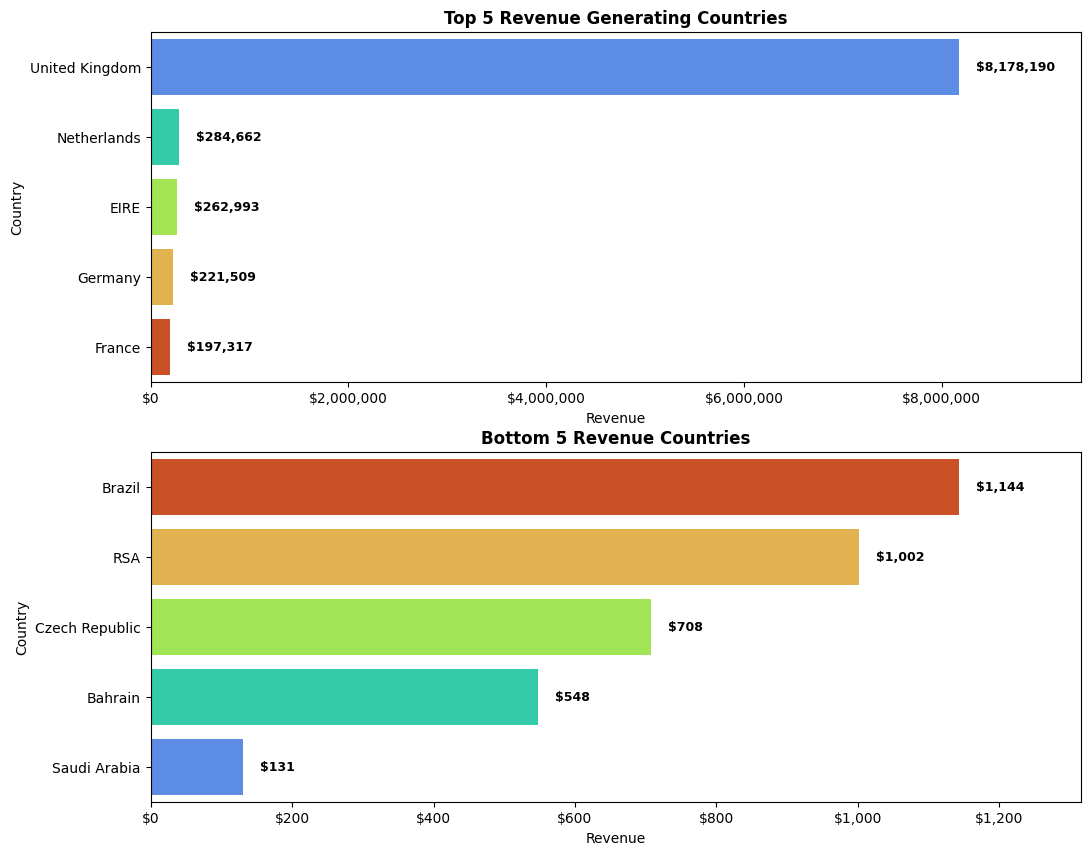

In [4]:
# calculate total revenue
df["total_revenue"] = df['quantity'] * df['unit_price'] 
top_5_countries = df.groupby('country')['total_revenue'].sum().sort_values(ascending=False).head(5).reset_index()
buttom_5_countries = df.groupby('country')['total_revenue'].sum().sort_values(ascending=False).tail(5).reset_index()

# set up the 2-row grid layout
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# set barplot for top 5 contries
sns.barplot(
    data=top_5_countries,
    x='total_revenue',
    y='country',
    hue='country',  
    palette='turbo',
    legend=False,
    ax=axes[0]
)

axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
axes[0].set_title("Top 5 Revenue Generating Countries", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Revenue", fontsize=10, fontweight='light')
axes[0].set_ylabel("Country", fontsize=10, fontweight='light')

# add revenue for each bar
for patch, val in zip(axes[0].patches, top_5_countries['total_revenue']):
    if patch.get_width() > 0:  # Verify it is a valid bar object
        axes[0].text(
            patch.get_width() + (axes[0].get_xlim()[1] * 0.02),  
            patch.get_y() + patch.get_height() / 2,              
            f"${val:,.0f}",                                      
            ha='left', 
            va='center', 
            fontsize=9, 
            fontweight='semibold'
        )

# set margin
axes[0].margins(x=0.15)

# set barplot for buttom 5 contries
sns.barplot(
    data=buttom_5_countries,
    x='total_revenue',
    y='country',
    hue='country',  
    palette='turbo_r',
    legend=False,
    ax=axes[1]
)

axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
axes[1].set_title("Bottom 5 Revenue Countries", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Revenue", fontsize=10, fontweight='light')
axes[1].set_ylabel("Country", fontsize=10, fontweight='light')

# add revenue for each bar
for patch, val in zip(axes[1].patches, buttom_5_countries['total_revenue']):
    if patch.get_width() > 0: 
        axes[1].text(
            patch.get_width() + (axes[1].get_xlim()[1] * 0.02),  
            patch.get_y() + patch.get_height() / 2,              
            f"${val:,.0f}",                                      
            ha='left', 
            va='center', 
            fontsize=9, 
            fontweight='semibold'
        )

# set margin
axes[1].margins(x=0.15, )

plt.show()

## 2. Which products contribute most to revenue?

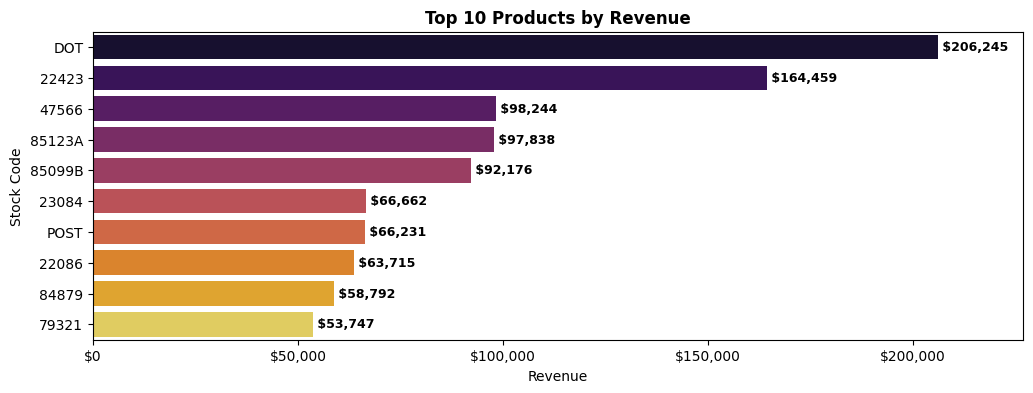

In [5]:
# turn total revenue to numeric / stock code to str
df['total_revenue'] = pd.to_numeric(df['total_revenue'], errors='coerce')
df["stock_code"] = df["stock_code"].astype(str)

top_10_products = (
    df.groupby('stock_code').agg(
        total_revenue=('total_revenue', 'sum'),
        units_sold=('quantity', 'sum')
    )
    .sort_values('total_revenue', ascending=False)
    .head(10)
    .reset_index()
)

# set size
plt.figure(figsize=(12, 4))

# set barplot
ax = sns.barplot(
    data=top_10_products,
    x='total_revenue',
    y='stock_code',
    hue='stock_code',
    palette='inferno',
    legend=False
)

# set ax format
ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter('${x:,.0f}')
)

# add revenue value to each bar
for patch, val in zip(
    ax.patches,
    top_10_products['total_revenue']
):
    ax.text(
        patch.get_width(),
        patch.get_y() + patch.get_height() / 2,
        f' ${val:,.0f}',
        ha='left',
        va='center',
        fontsize=9,
        fontweight='semibold'
    )

# set margin
ax.margins(x=0.10)

ax.set_title('Top 10 Products by Revenue',fontsize=12,fontweight='bold')
ax.set_xlabel('Revenue', fontsize=10, fontweight='light')
ax.set_ylabel('Stock Code', fontsize=10, fontweight='light')

plt.show()


## 3. Product Quantity vs Revenue

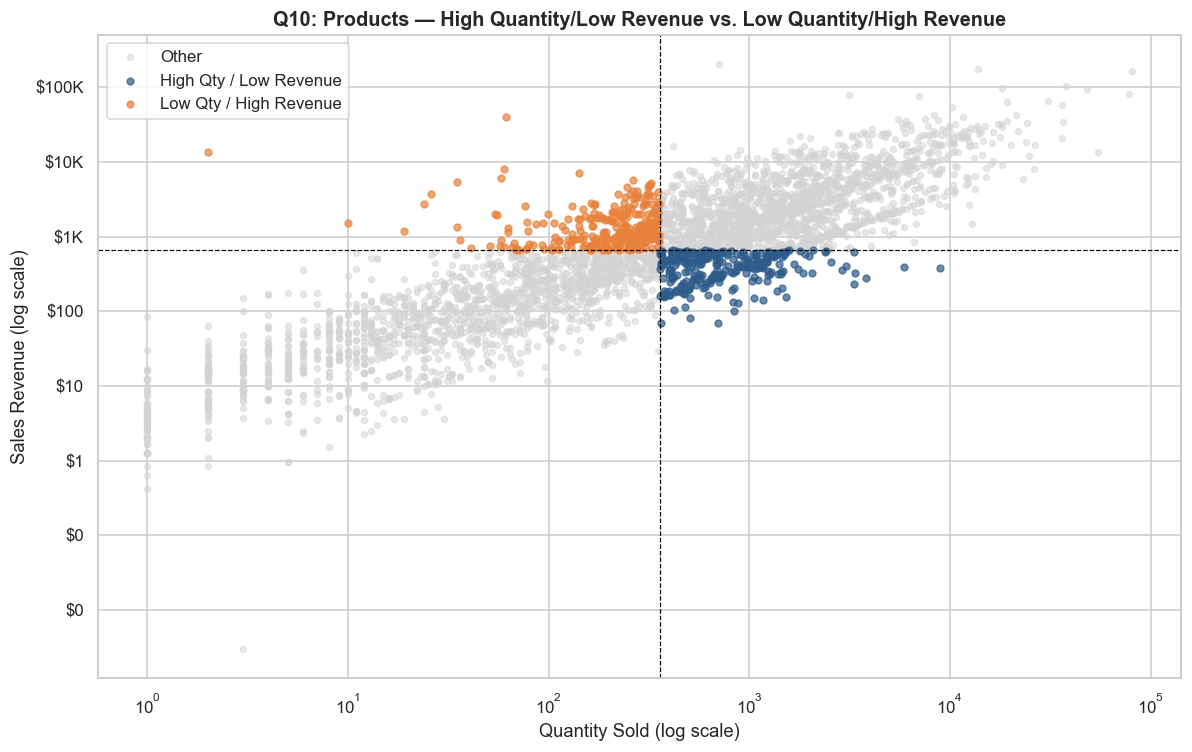

In [23]:
prod_stats = sales.groupby("description").agg(
    quantity=("quantity", "sum"),
    sales_revenue=("sales_revenue", "sum"),
).dropna()
prod_stats = prod_stats[(prod_stats["quantity"] > 0) & (prod_stats["sales_revenue"] > 0)]

qty_median = prod_stats["quantity"].median()
rev_median = prod_stats["sales_revenue"].median()

def quadrant(row):
    if row["quantity"] >= qty_median and row["sales_revenue"] < rev_median:
        return "High Qty / Low Revenue"
    if row["quantity"] < qty_median and row["sales_revenue"] >= rev_median:
        return "Low Qty / High Revenue"
    return "Other"

prod_stats["quadrant"] = prod_stats.apply(quadrant, axis=1)
highlight = prod_stats[prod_stats["quadrant"] != "Other"]
other = prod_stats[prod_stats["quadrant"] == "Other"]

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(other["quantity"], other["sales_revenue"], color="lightgrey", alpha=0.5, s=15, label="Other")
for seg, color in [("High Qty / Low Revenue", ACCENT), ("Low Qty / High Revenue", ACCENT2)]:
    sub = highlight[highlight["quadrant"] == seg]
    ax.scatter(sub["quantity"], sub["sales_revenue"], color=color, alpha=0.7, s=20, label=seg)

ax.set_xscale("log"); ax.set_yscale("log")
ax.axvline(qty_median, color="black", linestyle="--", linewidth=0.8)
ax.axhline(rev_median, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Quantity Sold (log scale)")
ax.set_ylabel("Sales Revenue (log scale)")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(money))
ax.set_title("Q10: Products — High Quantity/Low Revenue vs. Low Quantity/High Revenue")
ax.legend()
fig.tight_layout()
plt.show()

## 4. How many times are the customers buying?

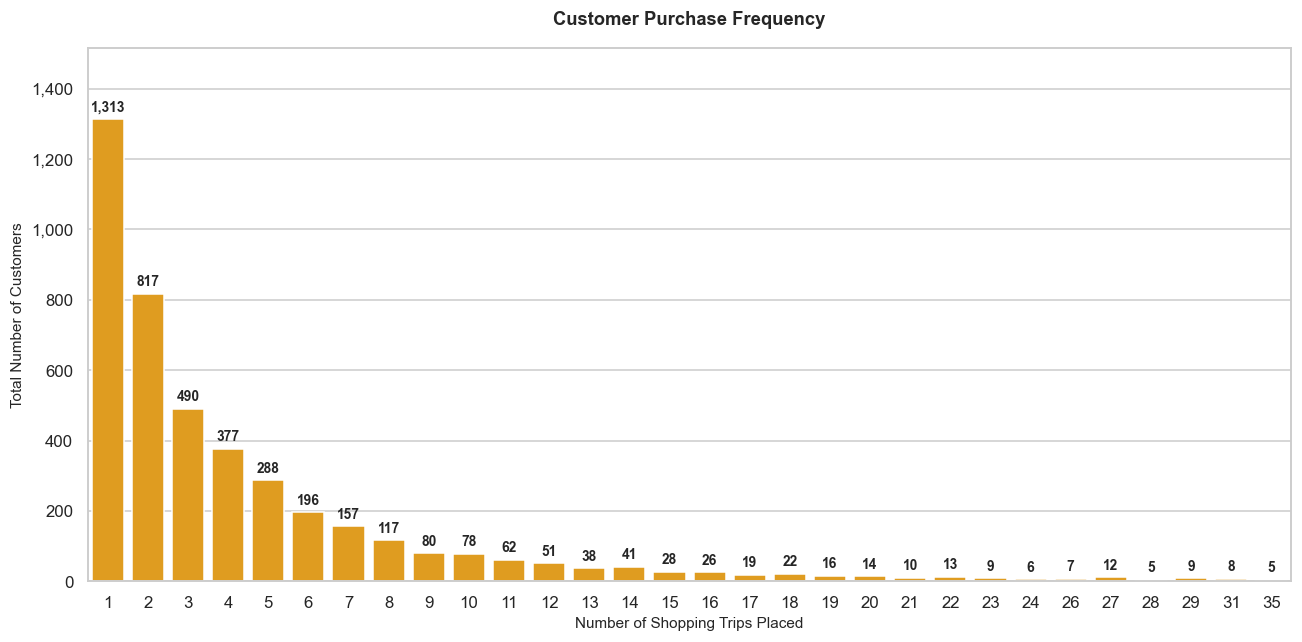

In [15]:
cus_orders = df.groupby('customer_id')['invoice_no'].nunique().reset_index()
cus_orders.columns = ['customer_id', 'number_of_trips']

order_dist = cus_orders['number_of_trips'].value_counts().head(30).reset_index()
order_dist.columns = ['number_of_trips', 'customer_count']
order_dist = order_dist.sort_values(by='number_of_trips')

plt.figure(figsize=(12, 6))

# plot
sns.barplot(
    data=order_dist,
    x="number_of_trips",
    y="customer_count",
    color='orange'
)

plt.title("Customer Purchase Frequency", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Number of Shopping Trips Placed", fontsize=10, fontweight='light')
plt.ylabel("Total Number of Customers", fontsize=10, fontweight='light')

# Format the Y-axis numbers with standard commas for clean counts
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# customer counts text at the tip of each bar
current_ax = plt.gca()
for patch, val in zip(current_ax.patches, order_dist['customer_count']):
    if patch.get_height() > 0:
        current_ax.text(
            patch.get_x() + patch.get_width() / 2,     
            patch.get_height() + (current_ax.get_ylim()[1] * 0.01),
            f"{val:,.0f}",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='semibold'
        )

current_ax.set_ylim(top=current_ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()


## 5. Top and Bottom 10 Products Contributing to Sale Revenue

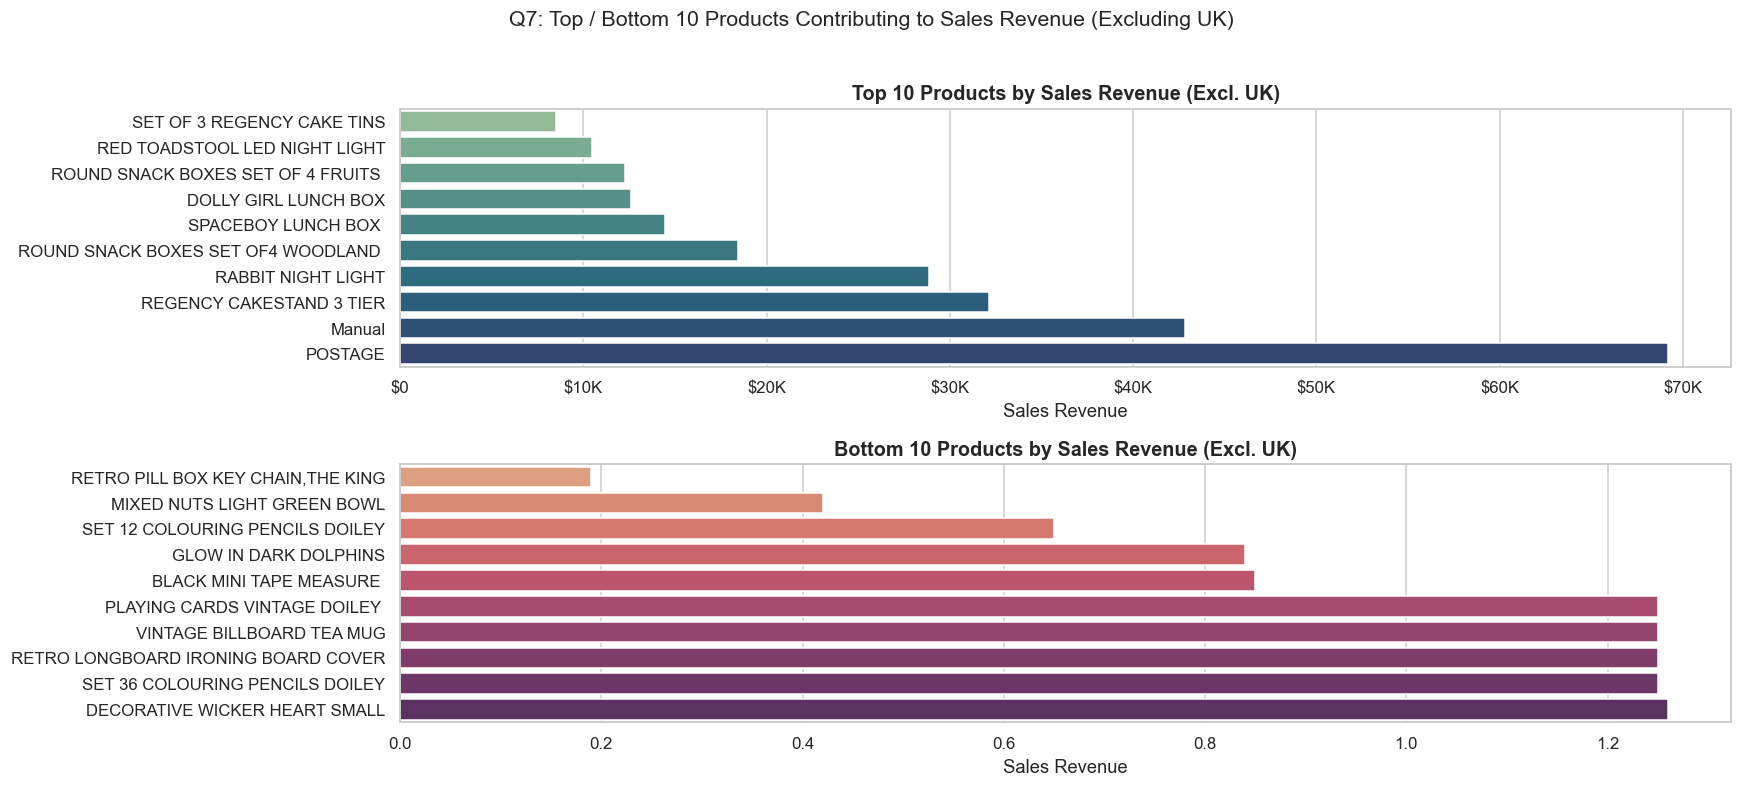

In [ ]:
sales_ex_uk = sales[sales["country"] != "United Kingdom"]
prod_rev_ex_uk = sales_ex_uk.groupby("description")["sales_revenue"].sum().sort_values(ascending=False)
prod_rev_ex_uk = prod_rev_ex_uk[prod_rev_ex_uk.index.notna()]
top10_products = prod_rev_ex_uk.head(10).sort_values()
bottom10_products = prod_rev_ex_uk.tail(10).sort_values()


fig, axes = plt.subplots(2, 1, figsize=(16, 7))

sns.barplot(x=top10_products.values, y=top10_products.index, ax=axes[0], palette="crest", hue=top10_products.index, legend=False)
axes[0].set_title("Top 10 Products by Sales Revenue (Excl. UK)")
axes[0].set_xlabel("Sales Revenue"); axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(money))

sns.barplot(x=bottom10_products.values, y=bottom10_products.index, ax=axes[1], palette="flare", hue=bottom10_products.index, legend=False)
axes[1].set_title("Bottom 10 Products by Sales Revenue (Excl. UK)")
axes[1].set_xlabel("Sales Revenue"); axes[1].set_ylabel("")

fig.suptitle("Q7: Top / Bottom 10 Products Contributing to Sales Revenue (Excluding UK)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 6. Understand overall customer purchasing behaviour in terms of RFM

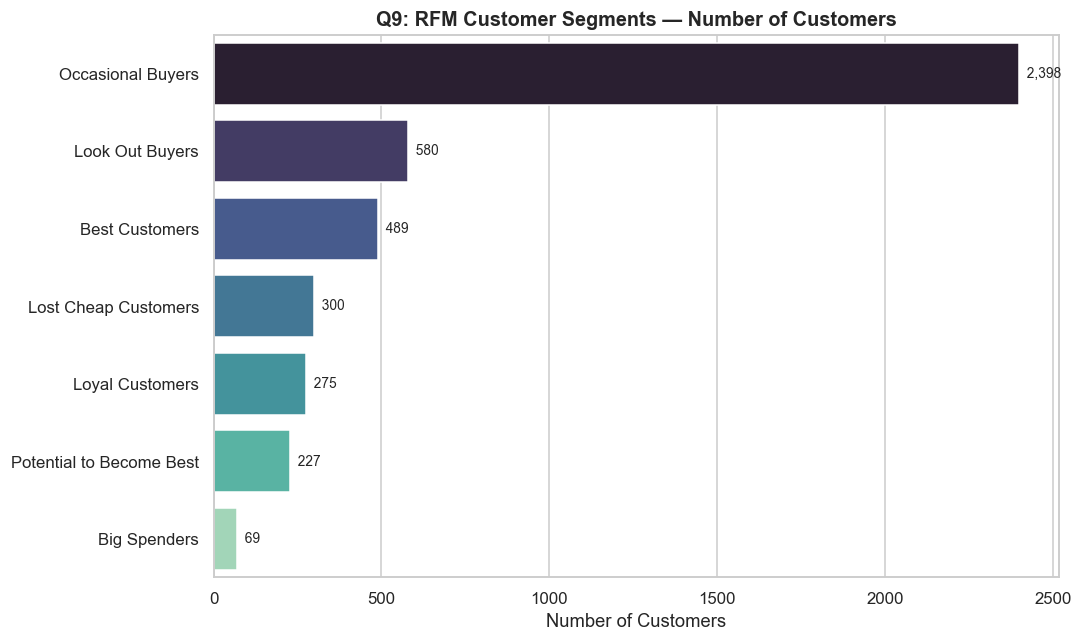

In [20]:
snapshot_date = sales["invoice_date"].max() + pd.Timedelta(days=1)
cust_sales = sales.dropna(subset=["customer_id"]).copy()
rfm = cust_sales.groupby("customer_id").agg(
    recency=("invoice_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("invoice_no", "nunique"),
    monetary=("sales_revenue", "sum"),
).reset_index()

r_score = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)   # low recency (days) = best = 4
f_score = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
m_score = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["R"], rfm["F"], rfm["M"] = r_score, f_score, m_score

def segment_customer(row):
    r, f, m = row["R"], row["F"], row["M"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Best Customers"
    if m >= 4 and f <= 2:
        return "Big Spenders"
    if f >= 4 and m < 4:
        return "Loyal Customers"
    if r >= 4 and f <= 2:
        return "Potential to Become Best"
    if r <= 2 and f >= 3:
        return "Look Out Buyers"
    if r == 1 and f == 1 and m == 1:
        return "Lost Cheap Customers"
    return "Occasional Buyers"

rfm["segment"] = rfm.apply(segment_customer, axis=1)
seg_counts = rfm["segment"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=seg_counts.values, y=seg_counts.index, palette="mako", ax=ax, hue=seg_counts.index, legend=False)
ax.set_title("Q9: RFM Customer Segments — Number of Customers")
ax.set_xlabel("Number of Customers"); ax.set_ylabel("")
for i, v in enumerate(seg_counts.values):
    ax.text(v, i, f"  {v:,}", va="center", fontsize=9)
fig.tight_layout()
plt.show()

seg_detail = rfm.groupby("segment")[["recency", "frequency", "monetary"]].mean().round(1)
seg_detail = seg_detail.reindex(seg_counts.index)

